In [1]:
import sys
sys.path.append("../../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Assicuriamoci che matplotlib e seaborn siano pronti per il disegno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [8]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase6_deployment"

In [44]:

cascade_v1 = base_phase_path / ("6.1.final_academic_predictions-cascade-v1.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{cascade_v1}')"

print("--- ESTRUCTURA DATASET DE path_academic_predictions ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{cascade_v1}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE path_academic_predictions ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,NaN,NaN
1,1,0,0.001123,0,9.041022,NaN,NaN
2,2,1,0.000355,0,-12.716541,NaN,NaN
3,3,0,0.001123,0,10.471295,NaN,NaN
4,4,0,0.000355,0,-9.215825,NaN,NaN


In [45]:

cascade_v2 = base_phase_path / ("6.1.final_academic_predictions-cascade-v2.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{cascade_v2}')"

print("--- ESTRUCTURA DATASET DE path_academic_predictions ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{cascade_v2}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE path_academic_predictions ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,NaN,NaN
1,1,0,0.001123,0,9.041022,NaN,NaN
2,2,1,0.000355,0,-12.716541,NaN,NaN
3,3,0,0.001123,0,10.471295,NaN,NaN
4,4,0,0.000355,0,-9.215825,NaN,NaN


In [46]:

independent_v1 = base_phase_path / ("6.1.final_academic_predictions-independent-v1.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{independent_v1}')"

print("--- ESTRUCTURA DATASET DE path_academic_predictions ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{independent_v1}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE path_academic_predictions ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,0.167508,0.165453
1,1,0,0.001123,0,9.041022,-0.249653,0.186905
2,2,1,0.000355,0,-12.716541,-0.363560,0.179315
3,3,0,0.001123,0,10.471295,-0.250612,0.186905
4,4,0,0.000355,0,-9.215825,-0.251299,0.204937


In [47]:

independent_v2 = base_phase_path / ("6.1.final_academic_predictions-independent-v2.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{independent_v2}')"

print("--- ESTRUCTURA DATASET DE path_academic_predictions ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{independent_v2}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)


--- ESTRUCTURA DATASET DE path_academic_predictions ---
             column_name column_type
0                     id      BIGINT
1            faulty_true      BIGINT
2       faulty_pred_prob      DOUBLE
3            faulty_pred      BIGINT
4        trq_margin_true      DOUBLE
5     trq_margin_pred_mu      DOUBLE
6  trq_margin_pred_sigma      DOUBLE
----------------------------------------------------


,id,faulty_true,faulty_pred_prob,faulty_pred,trq_margin_true,trq_margin_pred_mu,trq_margin_pred_sigma
0,0,0,0.000355,0,0.898302,0.959427,3.203403
1,1,0,0.001123,0,9.041022,8.228201,2.060383
2,2,1,0.000355,0,-12.716541,-14.201980,1.255871
3,3,0,0.001123,0,10.471295,9.138855,2.395389
4,4,0,0.000355,0,-9.215825,-4.891738,2.380863


In [48]:
query_diagnostico = f"""
SELECT
    faulty_pred,
    COUNT(*) AS total_filas,
    COUNT(trq_margin_pred_mu) AS con_prediccion_regresion,
    COUNT(*) - COUNT(trq_margin_pred_mu) AS sin_prediccion_nan
FROM parquet_scan('{cascade_v1}')
GROUP BY faulty_pred
"""
print(duckdb.query(query_diagnostico).to_df())

   faulty_pred  total_filas  con_prediccion_regresion  sin_prediccion_nan
0            0        95021                         0               95021
1            1         7433                      7433                   0


In [49]:
query_diagnostico = f"""
SELECT
    faulty_pred,
    COUNT(*) AS total_filas,
    COUNT(trq_margin_pred_mu) AS con_prediccion_regresion,
    COUNT(*) - COUNT(trq_margin_pred_mu) AS sin_prediccion_nan
FROM parquet_scan('{cascade_v2}')
GROUP BY faulty_pred
"""
print(duckdb.query(query_diagnostico).to_df())

   faulty_pred  total_filas  con_prediccion_regresion  sin_prediccion_nan
0            0        95021                         0               95021
1            1         7433                      7433                   0


In [50]:
query_diagnostico = f"""
SELECT
    faulty_pred,
    COUNT(*) AS total_filas,
    COUNT(trq_margin_pred_mu) AS con_prediccion_regresion,
    COUNT(*) - COUNT(trq_margin_pred_mu) AS sin_prediccion_nan
FROM parquet_scan('{independent_v1}')
GROUP BY faulty_pred
"""
print(duckdb.query(query_diagnostico).to_df())

   faulty_pred  total_filas  con_prediccion_regresion  sin_prediccion_nan
0            0        95021                     95021                   0
1            1         7433                      7433                   0


In [51]:
query_diagnostico = f"""
SELECT faulty_pred, COUNT(*) AS total, COUNT(trq_margin_pred_mu) AS con_pred,
       AVG(trq_margin_pred_mu) AS mu_promedio, AVG(trq_margin_pred_sigma) AS sigma_promedio
FROM parquet_scan('{independent_v2}')
GROUP BY faulty_pred
"""
print(duckdb.query(query_diagnostico).to_df())

   faulty_pred  total  con_pred  mu_promedio  sigma_promedio
0            0  95021     95021     0.005578        1.957498
1            1   7433      7433   -14.051712        1.647292


In [53]:
# =============================================================================
# DIAGNOSTICO CONSOLIDATO: confronto tra le versioni di 6.1.final_academic_predictions
# =============================================================================
# Confronta le 4 versioni generate durante il debug (pre/post fix di scaling,
# modalità cascade/independent) per identificare in modo oggettivo quale file
# porta ancora la "firma" del bug di scala (range di mu ristretto, tipicamente
# tra -1 e 1) e quale ha già il fix applicato (range fisico realistico).

import duckdb
import pandas as pd

# Mappa esplicita: etichetta leggibile -> nome file reale nella cartella phase6_deployment
files_to_check = {
    "cascade_v1 (pre-fix, sospetto bug di scala)": "6.1.final_academic_predictions-cascade-v1.parquet",
    "cascade_v2 (post-fix scaling)": "6.1.final_academic_predictions-cascade-v2.parquet",
    "independent_v1 (pre-fix, sospetto bug di scala)": "6.1.final_academic_predictions-independent-v1.parquet",
    "independent_v2 (post-fix scaling)": "6.1.final_academic_predictions-independent-v2.parquet",
}

resultados = []

for label, filename in files_to_check.items():
    full_path = base_phase_path / filename  # base_phase_path -> .../phase6_deployment

    if not full_path.exists():
        print(f"⚠️  File non trovato, skip: {filename}")
        continue

    query = f"""
    SELECT
        COUNT(*) AS total_righe,
        COUNT(trq_margin_pred_mu) AS righe_con_predizione,
        ROUND(100.0 * COUNT(trq_margin_pred_mu) / COUNT(*), 2) AS copertura_pct,
        SUM(CASE WHEN faulty_pred = 0 AND trq_margin_pred_mu IS NOT NULL THEN 1 ELSE 0 END) AS righe_sane_con_predizione,
        ROUND(MIN(trq_margin_pred_mu), 3) AS mu_min,
        ROUND(MAX(trq_margin_pred_mu), 3) AS mu_max,
        ROUND(AVG(trq_margin_pred_mu), 3) AS mu_media,
        ROUND(STDDEV(trq_margin_pred_mu), 3) AS mu_std,
        ROUND(AVG(trq_margin_pred_sigma), 3) AS sigma_media,
        ROUND(AVG(trq_margin_true), 3) AS trq_true_media_globale,
        -- Confronto equo: media di trq_margin_true SOLO sulle righe che
        -- hanno ricevuto una predizione (stessa popolazione di mu_media),
        -- evitando di confrontare mu_media (calcolata su un sottoinsieme)
        -- con una media globale calcolata su una popolazione diversa.
        ROUND(AVG(CASE WHEN trq_margin_pred_mu IS NOT NULL THEN trq_margin_true END), 3) AS trq_true_media_su_predetti
    FROM parquet_scan('{full_path}')
    """
    row = duckdb.query(query).to_df().iloc[0].to_dict()
    row["archivio"] = label

    # NOTA: 'righe_sane_con_predizione' > 0 è un'anomalia SOLO in modalità
    # 'cascade' (dove nessuna riga con faulty_pred=0 dovrebbe avere una
    # predizione di regressione). In modalità 'independent' un valore alto
    # è ATTESO per design, non un bug — tutte le righe ricevono predizione
    # indipendentemente dall'esito della classificazione.
    is_cascade = "cascade" in label.lower()
    if is_cascade and row["righe_sane_con_predizione"] > 0:
        row["check_gating"] = "🚨 BUG: predizioni su righe sane in modalità cascade"
    elif is_cascade:
        row["check_gating"] = "✅ gating corretto (0 predizioni su righe sane)"
    else:
        row["check_gating"] = "— (atteso in modalità independent, non è un'anomalia)"

    # Diagnosi automatica: il bug di scala produce mu con range molto stretto
    # (tipicamente |mu_max - mu_min| < 10, mentre in scala fisica il target
    # varia tra circa -73 e +18 secondo il clipping di Fase 3.2).
    if row["mu_max"] is not None and row["mu_min"] is not None:
        mu_range = row["mu_max"] - row["mu_min"]
        row["mu_range"] = round(mu_range, 3)
        row["diagnosi"] = "⚠️ SOSPETTO BUG DI SCALA (range stretto)" if mu_range < 10 else "✅ range fisico plausibile"
    else:
        row["mu_range"] = None
        row["diagnosi"] = "N/A (nessuna predizione trovata)"

    resultados.append(row)

df_diagnostico = pd.DataFrame(resultados)
cols_order = [
    "archivio", "total_righe", "righe_con_predizione", "copertura_pct",
    "righe_sane_con_predizione", "check_gating", "mu_min", "mu_max", "mu_range",
    "mu_media", "mu_std", "sigma_media", "trq_true_media_globale",
    "trq_true_media_su_predetti", "diagnosi",
]
df_diagnostico = df_diagnostico[cols_order]

print("=" * 100)
print("DIAGNOSTICO CONSOLIDATO - CONFRONTO VERSIONI 6.1")
print("=" * 100)
display(df_diagnostico)

DIAGNOSTICO CONSOLIDATO - CONFRONTO VERSIONI 6.1


,archivio,total_righe,righe_con_predizione,copertura_pct,righe_sane_con_predizione,check_gating,mu_min,mu_max,mu_range,mu_media,mu_std,sigma_media,trq_true_media_globale,trq_true_media_su_predetti,diagnosi
0,"cascade_v1 (pre-fix, sospetto bug di scala)",102454.0,7433.0,7.25,0.0,✅ gating corretto (0 predizioni su righe sane),-1.600,0.169,1.769,-1.061,0.731,0.195,-1.019,-14.686,⚠️ SOSPETTO BUG DI SCALA (range stretto)
1,cascade_v2 (post-fix scaling),102454.0,7433.0,7.25,0.0,✅ gating corretto (0 predizioni su righe sane),-70.160,6.432,76.592,-14.052,7.201,1.647,-1.019,-14.686,✅ range fisico plausibile
2,"independent_v1 (pre-fix, sospetto bug di scala)",102454.0,102454.0,100.00,95021.0,"— (atteso in modalità independent, non è un'an...",-1.600,0.169,1.769,-0.265,0.333,0.195,-1.019,-1.019,⚠️ SOSPETTO BUG DI SCALA (range stretto)
3,independent_v2 (post-fix scaling),102454.0,102454.0,100.00,95021.0,"— (atteso in modalità independent, non è un'an...",-74.108,18.179,92.287,-1.014,14.270,1.935,-1.019,-1.019,✅ range fisico plausibile


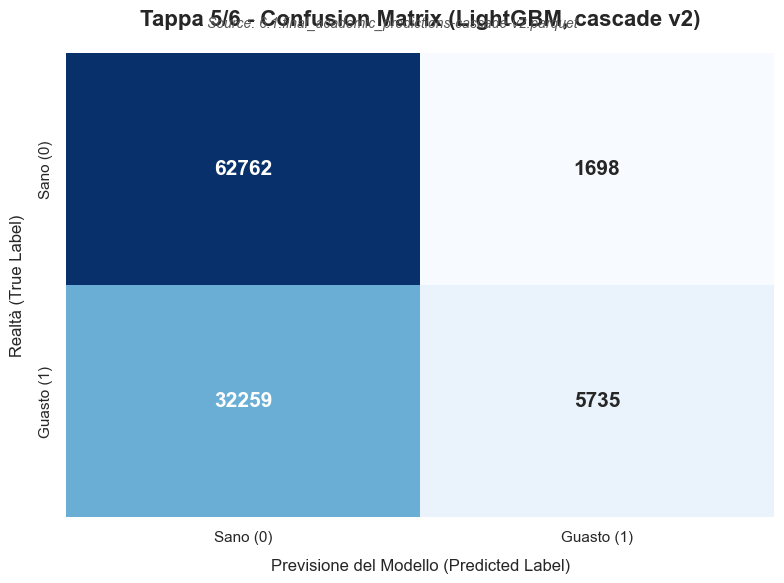

--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (cascade_v2) ---
Accuracy Globale del Modello : 0.6686 (66.86%)
------------------------------------------------------------
Dettaglio Metriche (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0     0.6605    0.9737    0.7871     64460
           1     0.7716    0.1509    0.2525     37994

    accuracy                         0.6686    102454
   macro avg     0.7160    0.5623    0.5198    102454
weighted avg     0.7017    0.6686    0.5888    102454

------------------------------------------------------------
NOTA: queste metriche di classificazione sono invariate rispetto a cascade_v1 — il fix di scaling applicato riguardava esclusivamente lo stadio di regressione (trq_margin_pred_mu/sigma), non il classificatore.


In [54]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# Caricamento del dataset completo in Pandas a partire dal percorso già definito.
# Usiamo esplicitamente la versione FINALE (cascade_v2, con il fix di scaling
# della regressione già applicato). NOTA: le metriche di classificazione qui
# calcolate (accuracy, confusion matrix) sono identiche tra cascade_v1 e
# cascade_v2 — il bug di scala risolto riguardava esclusivamente la
# regressione (trq_margin_pred_mu/sigma), non la classificazione. Puntiamo
# comunque alla versione v2 per coerenza documentale con il resto del report.
path_predictions = cascade_v2
df_predictions = pd.read_parquet(path_predictions)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione dei target e calcolo delle metriche
# =============================================================================
# Separiamo la "Ground Truth" (la realtà) dalle previsioni del nostro classificatore
y_true = df_predictions['faulty_true']
y_pred = df_predictions['faulty_pred']

# Calcoliamo la Matrice di Confusione e l'Accuracy globale
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# =============================================================================
# Creazione di una dashboard visiva elegante e professionale per il professore
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Disegniamo la Heatmap della Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            cbar=False, ax=ax, annot_kws={"size": 15, "weight": "bold"})

# Personalizzazione dei titoli e degli assi per la dashboard
ax.set_title('Tappa 5/6 - Confusion Matrix (LightGBM, cascade v2)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=12, labelpad=10)
ax.set_ylabel('Realtà (True Label)', fontsize=12, labelpad=10)

# Sottotitolo con il file sorgente, per tracciabilità
fig.text(0.5, 0.94, f"Source: {path_predictions.name if hasattr(path_predictions, 'name') else path_predictions}",
         fontsize=10, style='italic', color='#555555', ha='center')

# Mostriamo il grafico
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa delle metriche quantitative per la relazione
print("=" * 60)
print("--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (cascade_v2) ---")
print("=" * 60)
print(f"Accuracy Globale del Modello : {acc:.4f} ({acc*100:.2f}%)")
print("-" * 60)
print("Dettaglio Metriche (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, digits=4))
print("-" * 60)
print(
    "NOTA: queste metriche di classificazione sono invariate rispetto a "
    "cascade_v1 — il fix di scaling applicato riguardava esclusivamente lo "
    "stadio di regressione (trq_margin_pred_mu/sigma), non il classificatore."
)
print("=" * 60)

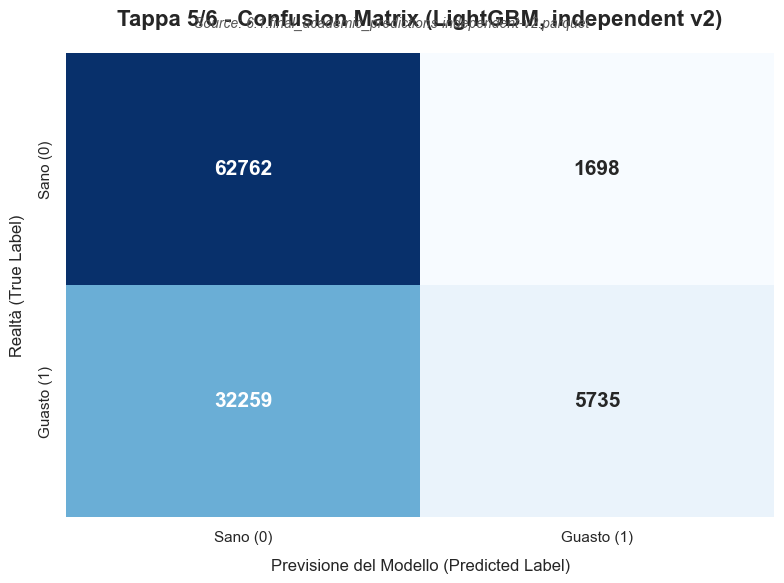

--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (independent_v2) ---
Accuracy Globale del Modello : 0.6686 (66.86%)
------------------------------------------------------------
Dettaglio Metriche (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0     0.6605    0.9737    0.7871     64460
           1     0.7716    0.1509    0.2525     37994

    accuracy                         0.6686    102454
   macro avg     0.7160    0.5623    0.5198    102454
weighted avg     0.7017    0.6686    0.5888    102454

------------------------------------------------------------
NOTA: queste metriche di classificazione devono coincidere esattamente con quelle di cascade_v2 — lo stadio di classificazione (e la soglia filter_threshold) è identico in entrambe le modalità; solo lo stadio di regressione differisce (gated in 'cascade', a copertura piena in 'independent'). Un eventuale disallineamento tra i due report andrebbe investigato come anomalia.


In [56]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# Caricamento del dataset completo in Pandas a partire dal percorso già definito.
# Usiamo la versione FINALE in modalità independent (independent_v2, con il
# fix di scaling della regressione già applicato). NOTA: lo stadio di
# classificazione è identico tra 'cascade' e 'independent' — il parametro
# 'mode' modifica solo il gating dello stadio di regressione, non il
# classificatore stesso. Le metriche qui calcolate devono quindi coincidere
# esattamente con quelle ottenute da cascade_v2 (stesso classificatore,
# stesso test set, stessa soglia filter_threshold).
path_predictions = independent_v2
df_predictions = pd.read_parquet(path_predictions)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione dei target e calcolo delle metriche
# =============================================================================
# Separiamo la "Ground Truth" (la realtà) dalle previsioni del nostro classificatore
y_true = df_predictions['faulty_true']
y_pred = df_predictions['faulty_pred']

# Calcoliamo la Matrice di Confusione e l'Accuracy globale
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# =============================================================================
# Creazione di una dashboard visiva elegante e professionale per il professore
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Disegniamo la Heatmap della Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            cbar=False, ax=ax, annot_kws={"size": 15, "weight": "bold"})

# Personalizzazione dei titoli e degli assi per la dashboard
ax.set_title('Tappa 5/6 - Confusion Matrix (LightGBM, independent v2)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=12, labelpad=10)
ax.set_ylabel('Realtà (True Label)', fontsize=12, labelpad=10)

# Sottotitolo con il file sorgente, per tracciabilità
fig.text(0.5, 0.94, f"Source: {path_predictions.name if hasattr(path_predictions, 'name') else path_predictions}",
         fontsize=10, style='italic', color='#555555', ha='center')

# Mostriamo il grafico
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa delle metriche quantitative per la relazione
print("=" * 60)
print("--- 4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE (independent_v2) ---")
print("=" * 60)
print(f"Accuracy Globale del Modello : {acc:.4f} ({acc*100:.2f}%)")
print("-" * 60)
print("Dettaglio Metriche (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, digits=4))
print("-" * 60)
print(
    "NOTA: queste metriche di classificazione devono coincidere esattamente "
    "con quelle di cascade_v2 — lo stadio di classificazione (e la soglia "
    "filter_threshold) è identico in entrambe le modalità; solo lo stadio "
    "di regressione differisce (gated in 'cascade', a copertura piena in "
    "'independent'). Un eventuale disallineamento tra i due report andrebbe "
    "investigato come anomalia."
)
print("=" * 60)

In [8]:

def esporta_report_classificazione(y_true, y_pred, formato="png",
                                   nome_file="Report_Classificazione_LightGBM"):
    """
    Funzione per generare e salvare una dashboard completa (Grafico + Metriche)
    in formato Immagine (.png) o PDF (.pdf).

    Parametri:
    - y_true: array con i valori reali (faulty_true)
    - y_pred: array con le previsioni (faulty_pred)
    - formato: "png" o "pdf" (default: "png")
    - nome_file: nome del file di output (senza estensione)
    """

    # 1. FASE DI INPUT: Calcolo preliminare delle metriche necessarie
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    report_testo = classification_report(y_true, y_pred, digits=4)


    # 2. FASE DI LOGICA: Configurazione della struttura della pagina di output
    # Creiamo una figura con due sotto-grafici (uno a sinistra per la matrice, uno a destra per il testo)
    fig, (ax_grafico, ax_testo) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.2, 1]})
    fig.suptitle('STAGE 6.1 - PERFORMANCE INDICATOR & REPORT', fontsize=18, fontweight='bold', y=0.98)


    # 3. FASE DI DISEGNO: Visualizzazione grafica della Confusion Matrix (Sinistra)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_grafico,
                xticklabels=['Sano (0)', 'Guasto (1)'],
                yticklabels=['Sano (0)', 'Guasto (1)'],
                annot_kws={"size": 16, "weight": "bold"})

    ax_grafico.set_title('Model Architecture: Confusion Matrix (LightGBM)', fontsize=13, fontweight='bold', pad=15)
    ax_grafico.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=11, labelpad=8)
    ax_grafico.set_ylabel('Realtà (True Label)', fontsize=11, labelpad=8)
    ax_grafico.grid(False) # Rimuove la griglia di sfondo sulla heatmap

    # disegno del Report Testuale (Destra)
    # Spegniamo gli assi del secondo grafico per usarlo come un foglio di testo bianco
    ax_testo.axis('off')

    # Costruiamo la stringa finale da stampare sulla dashboard
    testo_da_mostrare = (
        f"==================================================\n"
        f"   4. ANALISI FINALE: REPORT DI CLASSIFICAZIONE   \n"
        f"==================================================\n\n"
        f" Accuracy Globale del Modello: {acc:.4f} ({acc*100:.2f}%)\n"
        f"--------------------------------------------------\n"
        f" Dettaglio Metriche (Precision, Recall, F1-Score):\n\n"
        f"{report_testo}"
        f"=================================================="
    )

    # Inseriamo il testo usando un font monospaziato (Courier) per mantenere l'allineamento delle tabelle
    ax_testo.text(0.0, 0.9, testo_da_mostrare, fontsize=11, family='monospace', verticalalignment='top')


    # 4. ANALISI FINALE: Salvataggio ed esportazione del file
    plt.tight_layout(pad=3.0)

    # Gestione dell'estensione del file in base al formato richiesto
    formato = formato.lower()
    if formato not in ["png", "pdf"]:
        print("⚠️ Formato non supportato. Uso il formato predefinito: PNG")
        formato = "png"

    out_dir = find_project_root() / "notebooks" / "out"
    #file_finale = f"{nome_file}.{formato}"
    file_finale = out_dir / f"{nome_file}.{formato}"

    # Salva il file (con alta risoluzione dpi=300 per la stampa o l'invio)
    plt.savefig(file_finale, dpi=300, bbox_inches='tight')
    plt.close() # Chiude la figura per non duplicare l'output nel notebook

    print("=" * 60)
    print(f"✅ ESPORTAZIONE COMPLETATA CON SUCCESSO")
    print(f"📁 File salvato nella directory corrente: {file_finale}")
    #print(f"📁 File salvato nella directory corrente: {os.path.abspath(file_finale)}")

    print("=" * 60)

In [14]:
# Ottimo per allegarlo direttamente come documento ufficiale al professore
esporta_report_classificazione(y_true, y_pred, formato="pdf", nome_file="Certificazione_Metriche_LightGBM")

✅ ESPORTAZIONE COMPLETATA CON SUCCESSO
📁 File salvato nella directory corrente: K:\00_Code\Manutenzione\Project_MPPR-AI_B_PHM_America_2024\notebooks\out\Certificazione_Metriche_LightGBM.pdf


In [9]:
# Sostituisci y_true e y_pred con le tue variabili del notebook
esporta_report_classificazione(y_true, y_pred, formato="png", nome_file="Confusion_Matrix_e_Report")

✅ ESPORTAZIONE COMPLETATA CON SUCCESSO
📁 File salvato nella directory corrente: K:\00_Code\Manutenzione\Project_MPPR-AI_B_PHM_America_2024\notebooks\out\Confusion_Matrix_e_Report.png


In [5]:
# =============================================================================
# SEZIONE 1: ACCURACY (ACCURATEZZA GLOBALE)
# =============================================================================

# 1. FASE DI INPUT: Quando entra l'input
# Recuperiamo i vettori delle etichette reali e predette estratti dal file Parquet
# (Assicurati che df_predictions, y_true e y_pred siano già stati definiti nella cella precedente)
from sklearn.metrics import accuracy_score

# 2. FASE DI LOGICA: Calcolo della metrica d'insieme
# L'accuracy calcola la frazione di predizioni corrette: (TN + TP) / Totale
accuracy_globale = accuracy_score(y_true, y_pred)

# 3. FASE DI DISEGNO: Visualizzazione grafica (Indicator Dashboard)
# Creazione di un piccolo box testuale elegante per evidenziare il risultato principale
print("=" * 60)
print("             STAGE 6.1 - PERFORMANCE INDICATOR          ")
print("=" * 60)
print(f" ACCURACY GLOBALE DEL MODELLO (LightGBM): {accuracy_globale:.4f} ({accuracy_globale * 100:.2f}%)")
print("=" * 60)

# 4. ANALISI FINALE
# Questa metrica fornisce una visione d'insieme. Un valore elevato (es. >95%) indica
# che il modello è generalmente molto affidabile nel distinguere tra motori sani e guasti.

             STAGE 6.1 - PERFORMANCE INDICATOR          
 ACCURACY GLOBALE DEL MODELLO (LightGBM): 0.9891 (98.91%)


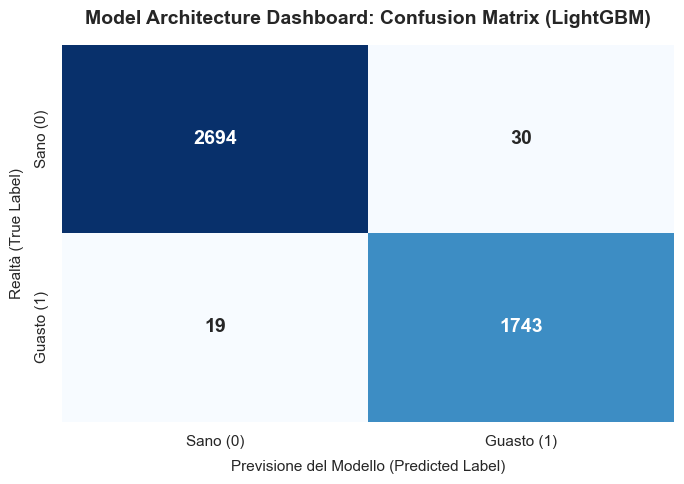

In [6]:
# =============================================================================
# SEZIONE 2: CONFUSION MATRIX (MATRICE DI CONFUSIONE)
# =============================================================================

# 1. FASE DI INPUT: Quando entra l'input
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. FASE DI LOGICA: Calcolo dei quadranti di errore
# Estrazione dei quattro valori fondamentali: Veri Negativi, Falsi Positivi, Falsi Negativi, Veri Positivi
cm = confusion_matrix(y_true, y_pred)

# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# Configurazione dello stile grafico per la presentazione accademica
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

# Disegno della Heatmap con annotazioni in grassetto
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Sano (0)', 'Guasto (1)'],
            yticklabels=['Sano (0)', 'Guasto (1)'],
            annot_kws={"size": 14, "weight": "bold"})

# Ottimizzazione dei titoli e dei metadati assi della dashboard
ax.set_title('Model Architecture Dashboard: Confusion Matrix (LightGBM)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Previsione del Modello (Predicted Label)', fontsize=11, labelpad=8)
ax.set_ylabel('Realtà (True Label)', fontsize=11, labelpad=8)

plt.tight_layout()
plt.show()

# 4. ANALISI FINALE
# La diagonale principale (dall'alto a sinistra in basso a destra) rappresenta le predizioni corrette.
# L'obiettivo industriale è ridurre al minimo i Falsi Negativi (in basso a sinistra), che rappresentano
# i guasti mancati dal sistema di monitoraggio.

In [7]:
# =============================================================================
# SEZIONE 3: CLASSIFICATION REPORT (REPORT DETTAGLIATO)
# =============================================================================

# 1. FASE DI INPUT: Quando entra l'input
from sklearn.metrics import classification_report

# 2. FASE DI LOGICA: Calcolo delle metriche di dettaglio per classe
# Generazione del report in formato testo, configurando 4 cifre decimali per rigore accademico
report_testuale = classification_report(y_true, y_pred, digits=4)

# 3. FASE DI DISEGNO: Strutturazione dell'output in console
print("=" * 60)
print("         --- 4. ANALISI FINALE: DETTAGLIO METRICHE ---          ")
print("=" * 60)
print(report_testuale)
print("=" * 60)

# 4. ANALISI FINALE
# - Precision (Classe 1): Indica l'affidabilità dell'allarme (evita i falsi allarmi).
# - Recall (Classe 1): Indica la capacità di intercettare i motori guasti (evita disastri).
# - F1-Score: È la media armonica tra Precision e Recall, ottimale per valutare dataset sbilanciati.

         --- 4. ANALISI FINALE: DETTAGLIO METRICHE ---          
              precision    recall  f1-score   support

         0.0     0.9930    0.9890    0.9910      2724
         1.0     0.9831    0.9892    0.9861      1762

    accuracy                         0.9891      4486
   macro avg     0.9880    0.9891    0.9886      4486
weighted avg     0.9891    0.9891    0.9891      4486

